In [ ]:
# CELL 1 — GPU + Mixed Precision
import tensorflow as tf
from tensorflow.keras import mixed_precision

print("GPUs:", tf.config.list_physical_devices("GPU"))
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [ ]:
# CELL 2 — Mount Drive + Paths + Run Config
from google.colab import drive
drive.mount("/content/drive")

import os

drive_dir = "/content/drive/MyDrive/mimic_bp"
work_dir  = "/content/mimic_bp"
os.makedirs(work_dir, exist_ok=True)

MODALITY   = "resp"   # "ecg" or "ppg" or "resp"
MODEL_TYPE = "lstm"

run_name = f"{MODALITY.upper()}_{MODEL_TYPE.upper()}_FULL30S"
ckpt_dir = os.path.join(drive_dir, "single_modality_runs", run_name)
os.makedirs(ckpt_dir, exist_ok=True)

print("run_name:", run_name)
print("ckpt_dir :", ckpt_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
run_name: RESP_LSTM_FULL30S
ckpt_dir : /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S


In [ ]:
# CELL 3 — Copy ZIPs from Drive
import shutil, zipfile, os

zips = ["abp", "ecg", "ppg", "resp", "labels"]

for name in zips:
    out_dir = os.path.join(work_dir, name)
    if os.path.exists(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f" {name} already extracted.")
        continue

    src = os.path.join(drive_dir, f"{name}.zip")
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing: {src}")

    dst = os.path.join(work_dir, f"{name}.zip")
    print("Copying", src, "->", dst)
    shutil.copy(src, dst)

    os.makedirs(out_dir, exist_ok=True)
    print("Unzipping", dst, "->", out_dir)
    with zipfile.ZipFile(dst, "r") as z:
        z.extractall(out_dir)

base_dir = work_dir
print("base_dir:", base_dir)


 abp already extracted.
 ecg already extracted.
 ppg already extracted.
 resp already extracted.
 labels already extracted.
base_dir: /content/mimic_bp


In [ ]:
# CELL 4 — Load splits + overlap check + inspect one subject
import ast, os
import numpy as np

def load_ids_fixed(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing split file: {path}")
    with open(path, "r") as f:
        t = f.read().strip()
    if t.startswith("[") and t.endswith("]"):
        return ast.literal_eval(t)
    return [line.strip() for line in t.splitlines() if line.strip()]

train_ids = load_ids_fixed(os.path.join(drive_dir, "train_subjects.txt"))
val_ids   = load_ids_fixed(os.path.join(drive_dir, "val_subjects.txt"))
test_ids  = load_ids_fixed(os.path.join(drive_dir, "test_subjects.txt"))

print("counts:", {"train": len(train_ids), "val": len(val_ids), "test": len(test_ids)})
print("Overlap train/val :", len(set(train_ids) & set(val_ids)))
print("Overlap train/test:", len(set(train_ids) & set(test_ids)))
print("Overlap val/test  :", len(set(val_ids) & set(test_ids)))

if len(train_ids) == 0:
    raise ValueError("train_ids is empty. Check split files.")

sid = train_ids[0]
print("sample train id:", sid)

sig_path = os.path.join(base_dir, MODALITY, f"{sid}_{MODALITY}.npy")
lab_path = os.path.join(base_dir, "labels", f"{sid}_labels.npy")

print("sig_path:", sig_path)
print("lab_path:", lab_path)
print("sig exists?", os.path.exists(sig_path))
print("lab exists?", os.path.exists(lab_path))

if not os.path.exists(sig_path) or not os.path.exists(lab_path):
    raise FileNotFoundError("Signal/label file missing for this subject.")

sig = np.load(sig_path)
lab = np.load(lab_path)

print("sig shape:", sig.shape, "dtype:", sig.dtype)
print("lab shape:", lab.shape, "dtype:", lab.dtype)
print("one segment length L =", sig.shape[-1])


counts: {'train': 1100, 'val': 195, 'test': 229}
Overlap train/val : 0
Overlap train/test: 0
Overlap val/test  : 0
sample train id: p085079
sig_path: /content/mimic_bp/resp/p085079_resp.npy
lab_path: /content/mimic_bp/labels/p085079_labels.npy
sig exists? True
lab exists? True
sig shape: (30, 3750) dtype: float64
lab shape: (30, 2) dtype: float64
one segment length L = 3750


In [ ]:
# CELL 5 — Dataset Generator

import numpy as np
import tensorflow as tf
import os

WINDOW_LEN = 3750
BATCH      = 64

def gen_full_segment(subject_ids, modality):
    sig_dir    = os.path.join(base_dir, modality)
    labels_dir = os.path.join(base_dir, "labels")

    missing = 0
    for sid in subject_ids:
        sig_path = os.path.join(sig_dir,    f"{sid}_{modality}.npy")
        lab_path = os.path.join(labels_dir, f"{sid}_labels.npy")

        if not (os.path.exists(sig_path) and os.path.exists(lab_path)):
            missing += 1
            continue

        sig    = np.load(sig_path)   # (30, 3750)
        labels = np.load(lab_path)   # (30, 2)

        for i in range(sig.shape[0]):
            x = sig[i].astype("float32").reshape(WINDOW_LEN, 1)
            y = labels[i].astype("float32")
            if np.isfinite(x).all() and np.isfinite(y).all():
                yield x, y

    if missing > 0:
        print(f" Missing files for {missing} subjects in this split.")

output_signature = (
    tf.TensorSpec(shape=(WINDOW_LEN, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(2,), dtype=tf.float32),
)

train_ds_raw = tf.data.Dataset.from_generator(lambda: gen_full_segment(train_ids, MODALITY),
                                              output_signature=output_signature)
val_ds_raw   = tf.data.Dataset.from_generator(lambda: gen_full_segment(val_ids,   MODALITY),
                                              output_signature=output_signature)
test_ds_raw  = tf.data.Dataset.from_generator(lambda: gen_full_segment(test_ids,  MODALITY),
                                              output_signature=output_signature)

print(" datasets ready (full 30s segments)")
print("WINDOW_LEN:", WINDOW_LEN, "| BATCH:", BATCH)


 datasets ready (full 30s segments)
WINDOW_LEN: 3750 | BATCH: 64


In [ ]:
# CELL 6 — Count samples + compute STEPS_PER_EPOCH / VAL_STEPS
import numpy as np
import os

def count_segments(subject_ids, modality):
    sig_dir = os.path.join(base_dir, modality)
    total = 0
    missing = 0
    for sid in subject_ids:
        sp = os.path.join(sig_dir, f"{sid}_{modality}.npy")
        if not os.path.exists(sp):
            missing += 1
            continue
        total += np.load(sp).shape[0]
    return total, missing

train_n, tr_miss = count_segments(train_ids, MODALITY)
val_n,   va_miss = count_segments(val_ids,   MODALITY)
test_n,  te_miss = count_segments(test_ids,  MODALITY)

print("Train samples:", train_n, "| missing subjects:", tr_miss)
print("Val samples  :", val_n,   "| missing subjects:", va_miss)
print("Test samples :", test_n,  "| missing subjects:", te_miss)

STEPS_PER_EPOCH = max(1, train_n // BATCH)
VAL_STEPS       = max(1, val_n   // BATCH)

print("STEPS_PER_EPOCH:", STEPS_PER_EPOCH)
print("VAL_STEPS      :", VAL_STEPS)


Train samples: 33000 | missing subjects: 0
Val samples  : 5850 | missing subjects: 0
Test samples : 6870 | missing subjects: 0
STEPS_PER_EPOCH: 515
VAL_STEPS      : 91


In [ ]:
# CELL 7 — Dataset statistics
import pandas as pd
import numpy as np
import os

def load_all_labels(subject_ids):
    labels_dir = os.path.join(base_dir, "labels")
    all_y = []
    miss = 0
    for sid in subject_ids:
        lp = os.path.join(labels_dir, f"{sid}_labels.npy")
        if not os.path.exists(lp):
            miss += 1
            continue
        y = np.load(lp).astype("float32")
        all_y.append(y)
    if not all_y:
        raise ValueError("No labels loaded.")
    return np.concatenate(all_y, axis=0), miss

y_train_all, miss_train = load_all_labels(train_ids)
y_val_all,   miss_val   = load_all_labels(val_ids)
y_test_all,  miss_test  = load_all_labels(test_ids)

def stats_1d(a):
    return float(a.min()), float(a.max()), float(a.mean()), float(a.std())

rows = []
for name, y in [("Train", y_train_all), ("Val", y_val_all), ("Test", y_test_all)]:
    sbp_min, sbp_max, sbp_mean, sbp_std = stats_1d(y[:,0])
    dbp_min, dbp_max, dbp_mean, dbp_std = stats_1d(y[:,1])
    rows.append([name, int(y.shape[0]), sbp_min, sbp_max, sbp_mean, sbp_std, dbp_min, dbp_max, dbp_mean, dbp_std])

df_stats = pd.DataFrame(rows, columns=[
    "Split","Samples","SBP_min","SBP_max","SBP_mean","SBP_std","DBP_min","DBP_max","DBP_mean","DBP_std"
])
print(df_stats)

dataset_stats = {
    "missing_label_subjects": {"train": int(miss_train), "val": int(miss_val), "test": int(miss_test)},
    "table": df_stats.to_dict(orient="records"),
}


   Split  Samples    SBP_min     SBP_max    SBP_mean    SBP_std    DBP_min  \
0  Train    33000  63.799999  185.000000  112.887573  17.975302  31.200001   
1    Val     5850  64.900002  176.899994  112.172546  17.222284  32.799999   
2   Test     6870  66.900002  185.800003  113.032715  17.638746  31.100000   

      DBP_max   DBP_mean    DBP_std  
0  115.599998  58.323711  12.359173  
1  112.300003  58.011024  12.152587  
2  108.599998  59.385536  11.800945  


In [ ]:
# CELL 8 — Normalization
import numpy as np
import tensorflow as tf

def estimate_mean_std(ds_raw, num_batches=200):
    total = 0
    s = 0.0
    s2 = 0.0
    for x, _ in ds_raw.batch(BATCH).take(num_batches):
        a = x.numpy().reshape(-1)
        s  += a.sum()
        s2 += (a*a).sum()
        total += a.size
    mean = s / total
    var  = (s2 / total) - mean**2
    std  = np.sqrt(max(var, 1e-12)) + 1e-8
    return float(mean), float(std)

mean, std = estimate_mean_std(train_ds_raw, num_batches=200)
mean_tf = tf.constant(mean, dtype=tf.float32)
std_tf  = tf.constant(std,  dtype=tf.float32)

def norm_xy(x, y):
    return (x - mean_tf) / std_tf, y

train_data = (train_ds_raw
              .map(norm_xy, num_parallel_calls=tf.data.AUTOTUNE)
              .shuffle(8000)
              .batch(BATCH)
              .prefetch(tf.data.AUTOTUNE)
              .repeat())

val_data = (val_ds_raw
            .map(norm_xy, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH)
            .prefetch(tf.data.AUTOTUNE)
            .repeat())

test_data = (test_ds_raw
             .map(norm_xy, num_parallel_calls=tf.data.AUTOTUNE)
             .batch(BATCH)
             .prefetch(tf.data.AUTOTUNE))

print(" Z-score (train only): mean =", mean, "| std =", std)


 Z-score (train only): mean = 0.18980593979358673 | std = 0.43738794326782227


In [ ]:
# CELL 9 — Baseline
import numpy as np

y_true = []
for _, yb in test_data:
    y_true.append(yb.numpy())
y_true = np.concatenate(y_true, axis=0)

train_mean_sbp = float(np.mean(y_train_all[:, 0]))
train_mean_dbp = float(np.mean(y_train_all[:, 1]))

baseline_pred = np.zeros_like(y_true)
baseline_pred[:, 0] = train_mean_sbp
baseline_pred[:, 1] = train_mean_dbp

baseline = {
    "train_mean_sbp": train_mean_sbp,
    "train_mean_dbp": train_mean_dbp,
    "mae_sbp": float(np.mean(np.abs(baseline_pred[:, 0] - y_true[:, 0]))),
    "mae_dbp": float(np.mean(np.abs(baseline_pred[:, 1] - y_true[:, 1]))),
    "mae_all": float(np.mean(np.abs(baseline_pred - y_true))),
    "mse_sbp": float(np.mean((baseline_pred[:, 0] - y_true[:, 0])**2)),
    "mse_dbp": float(np.mean((baseline_pred[:, 1] - y_true[:, 1])**2)),
    "mse_all": float(np.mean((baseline_pred - y_true)**2)),
}

print("=== Baseline (Train Mean) ===")
print("Train mean SBP:", baseline["train_mean_sbp"], "| Train mean DBP:", baseline["train_mean_dbp"])
print("MAE ALL:", baseline["mae_all"])
print("MAE SBP:", baseline["mae_sbp"])
print("MAE DBP:", baseline["mae_dbp"])
print("MSE ALL:", baseline["mse_all"])
print("MSE SBP:", baseline["mse_sbp"])
print("MSE DBP:", baseline["mse_dbp"])


=== Baseline (Train Mean) ===
Train mean SBP: 112.8875732421875 | Train mean DBP: 58.32371139526367
MAE ALL: 11.789267539978027
MAE SBP: 14.218526840209961
MAE DBP: 9.360006332397461
MSE ALL: 225.76808166503906
MSE SBP: 311.14642333984375
MSE DBP: 140.38975524902344


In [ ]:
# CELL 10 — Callbacks
import os, time
import tensorflow as tf

EPOCHS       = 100
SAVE_EVERY_N = 10
best_path    = os.path.join(ckpt_dir, f"best_{run_name}.keras")

class TimeInLogs(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["time_sec"] = time.time() - self.t0

class SaveEveryN(tf.keras.callbacks.Callback):
    def __init__(self, n=10):
        super().__init__()
        self.n = n
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.n == 0:
            path = os.path.join(ckpt_dir, f"checkpoint_{run_name}_epoch_{epoch+1}.keras")
            self.model.save(path)
            print("\n Saved:", path)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6),
    TimeInLogs(),
    SaveEveryN(n=SAVE_EVERY_N),
]

print("best_path:", best_path)


best_path: /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/best_RESP_LSTM_FULL30S.keras


In [ ]:
# CELL 11 — Build Model
import tensorflow as tf
from tensorflow.keras import layers

def build_model(model_type: str, window_len: int):
    model_type = model_type.lower()

    # ========= CNN =========
    if model_type == "cnn":
        model = tf.keras.Sequential([
            layers.Input(shape=(window_len, 1)),

            layers.Conv1D(32, 9, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling1D(2),

            layers.Conv1D(64, 7, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling1D(2),

            layers.Conv1D(128, 5, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling1D(2),

            layers.Conv1D(256, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),

            layers.GlobalAveragePooling1D(),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32"),
        ])
        return model

    # ========= LSTM =========
    if model_type == "lstm":
        model = tf.keras.Sequential([
            layers.Input(shape=(window_len, 1)),
            layers.LSTM(64, return_sequences=True),
            layers.Dropout(0.2),
            layers.LSTM(64),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32"),
        ])
        return model

    # ========= RNN =========
    if model_type == "rnn":
        model = tf.keras.Sequential([
            layers.Input(shape=(window_len, 1)),
            layers.SimpleRNN(64, return_sequences=True),
            layers.Dropout(0.2),
            layers.SimpleRNN(64),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32"),
        ])
        return model

    # ========= GRU =========
    if model_type == "gru":
        model = tf.keras.Sequential([
            layers.Input(shape=(window_len, 1)),
            layers.GRU(64, return_sequences=True),
            layers.Dropout(0.2),
            layers.GRU(64),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32"),
        ])
        return model

    # ========= BiLSTM =========
    if model_type == "bilstm":
        model = tf.keras.Sequential([
            layers.Input(shape=(window_len, 1)),
            layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
            layers.Dropout(0.2),
            layers.Bidirectional(layers.LSTM(64)),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32"),
        ])
        return model

    raise ValueError("MODEL_TYPE must be one of: cnn, lstm, rnn, gru, bilstm")


def mae_sbp(y_true_t, y_pred_t):
    return tf.reduce_mean(tf.abs(y_pred_t[:, 0] - y_true_t[:, 0]))

def mae_dbp(y_true_t, y_pred_t):
    return tf.reduce_mean(tf.abs(y_pred_t[:, 1] - y_true_t[:, 1]))


model = build_model(MODEL_TYPE, WINDOW_LEN)

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(delta=10.0),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae_all"),
        mae_sbp,
        mae_dbp,
        tf.keras.metrics.MeanSquaredError(name="mse_all"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3750, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3750, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,498 (228.51 KB)

 Trainable params: 58,498 (228.51 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# CELL 12 — Train

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1

)


Epoch 1/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 136s 246ms/step - loss: 641.9108 - mae_all: 69.1244 - mae_dbp: 44.3073 - mae_sbp: 93.9416 - mse_all: 6009.3066 - val_loss: 76.1547 - val_mae_all: 11.7190 - val_mae_dbp: 9.5499 - val_mae_sbp: 13.8882 - val_mse_all: 222.7187 - learning_rate: 3.0000e-04 - time_sec: 135.9123
Epoch 2/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 129s 250ms/step - loss: 98.7821 - mae_all: 14.0885 - mae_dbp: 10.9259 - mae_sbp: 17.2522 - mse_all: 332.2956 - val_loss: 76.1517 - val_mae_all: 11.7189 - val_mae_dbp: 9.5479 - val_mae_sbp: 13.8899 - val_mse_all: 222.4495 - learning_rate: 3.0000e-04 - time_sec: 129.4063
Epoch 3/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 131s 254ms/step - loss: 97.5526 - mae_all: 13.9565 - mae_dbp: 10.7483 - mae_sbp: 17.1520 - mse_all: 326.4577 - val_loss: 76.4462 - val_mae_all: 11.7519 - val_mae_dbp: 9.5790 - val_mae_sbp: 13.9247 - val_mse_all: 222.0977 - learning_rate: 3.0000e-04 - time_sec: 130.9763
Epoch 4/100
515/515 ━━━━━━━━━━━━━━━━━━━━ 126s 244ms/step - loss: 

In [17]:
# CELL 13 — Evaluate
import numpy as np
import tensorflow as tf

def evaluate_best_model(best_path, model_name="MODEL"):
    best_model = tf.keras.models.load_model(best_path, compile=False)
    y_pred = best_model.predict(test_data, verbose=0)

    metrics = {
        "name": model_name,
        "mae_sbp": float(np.mean(np.abs(y_pred[:, 0] - y_true[:, 0]))),
        "mae_dbp": float(np.mean(np.abs(y_pred[:, 1] - y_true[:, 1]))),
        "mae_all": float(np.mean(np.abs(y_pred - y_true))),
        "mse_sbp": float(np.mean((y_pred[:, 0] - y_true[:, 0])**2)),
        "mse_dbp": float(np.mean((y_pred[:, 1] - y_true[:, 1])**2)),
        "mse_all": float(np.mean((y_pred - y_true)**2)),
        "best_model_path": best_path,
    }

    print(f"=== {model_name} ===")
    print("MAE ALL:", metrics["mae_all"])
    print("MAE SBP:", metrics["mae_sbp"])
    print("MAE DBP:", metrics["mae_dbp"])
    print("MSE ALL:", metrics["mse_all"])
    print("MSE SBP:", metrics["mse_sbp"])
    print("MSE DBP:", metrics["mse_dbp"])
    return metrics


In [18]:
# Run evaluation (THIS CREATES model_metrics)

model_metrics = evaluate_best_model(best_path, model_name=run_name)


=== RESP_LSTM_FULL30S ===
MAE ALL: 11.794751167297363
MAE SBP: 14.199962615966797
MAE DBP: 9.389538764953613
MSE ALL: 229.95779418945312
MSE SBP: 315.6307067871094
MSE DBP: 144.2848663330078


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [19]:
# CELL 14 — Save results
import json
import pandas as pd
import os

results = {
    "run_name": run_name,
    "modality": MODALITY,
    "model_type": MODEL_TYPE,
    "window_len": int(WINDOW_LEN),
    "batch": int(BATCH),
    "epochs": int(EPOCHS),
    "steps_per_epoch": int(STEPS_PER_EPOCH),
    "val_steps": int(VAL_STEPS),
    "train_zscore_mean": float(mean),
    "train_zscore_std": float(std),
    "baseline": baseline,
    "model": model_metrics,
    "dataset_stats": dataset_stats,
}

json_path = os.path.join(ckpt_dir, f"results_{run_name}.json")
csv_path  = os.path.join(ckpt_dir, f"results_{run_name}.csv")

with open(json_path, "w") as f:
    json.dump(results, f, indent=2)

row = {
    "run_name": run_name,
    "modality": MODALITY,
    "model_type": MODEL_TYPE,
    "window_len": int(WINDOW_LEN),
    "batch": int(BATCH),
    "train_mean": float(mean),
    "train_std": float(std),

    "baseline_mae_all": baseline["mae_all"],
    "baseline_mae_sbp": baseline["mae_sbp"],
    "baseline_mae_dbp": baseline["mae_dbp"],
    "baseline_mse_all": baseline["mse_all"],
    "baseline_mse_sbp": baseline["mse_sbp"],
    "baseline_mse_dbp": baseline["mse_dbp"],

    "model_mae_all": model_metrics["mae_all"],
    "model_mae_sbp": model_metrics["mae_sbp"],
    "model_mae_dbp": model_metrics["mae_dbp"],
    "model_mse_all": model_metrics["mse_all"],
    "model_mse_sbp": model_metrics["mse_sbp"],
    "model_mse_dbp": model_metrics["mse_dbp"],

    "best_model_path": model_metrics["best_model_path"],
}

pd.DataFrame([row]).to_csv(csv_path, index=False)

print(" Saved JSON:", json_path)
print(" Saved CSV :", csv_path)


 Saved JSON: /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/results_RESP_LSTM_FULL30S.json
 Saved CSV : /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/results_RESP_LSTM_FULL30S.csv


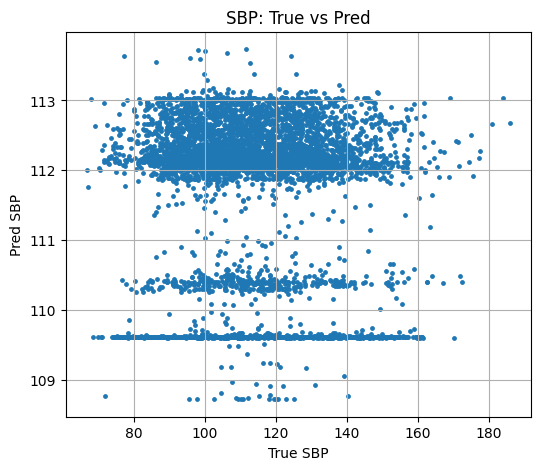

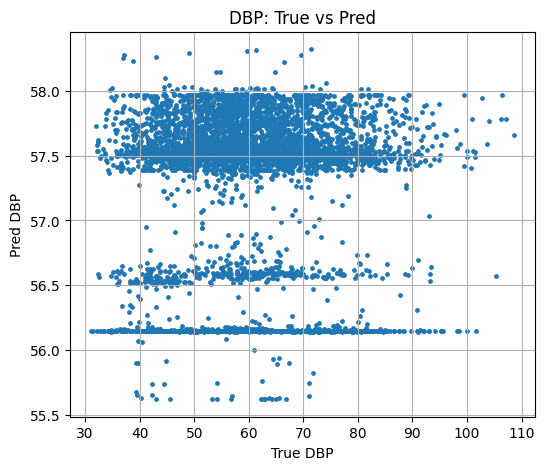

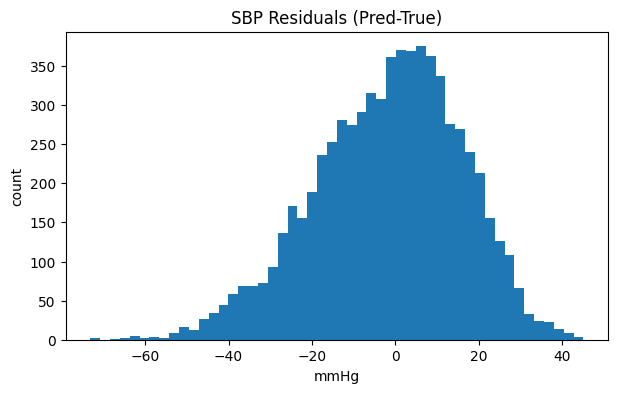

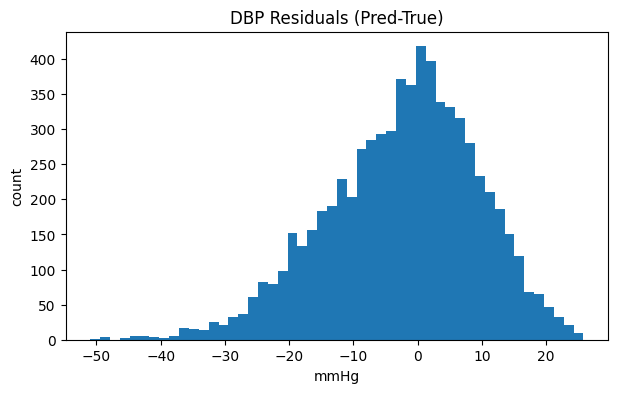

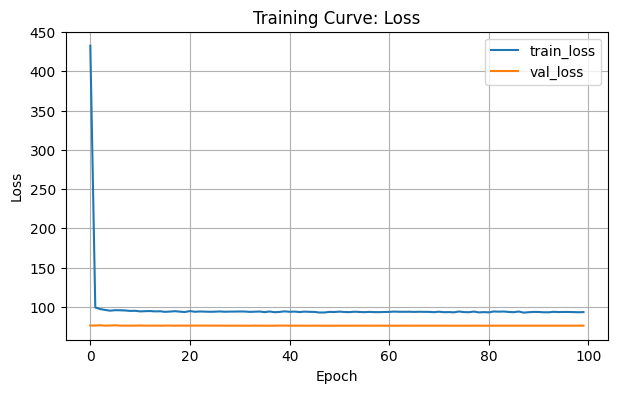

 Saved plots to: /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots
 - /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots/RESP_LSTM_FULL30S_SBP_scatter.png
 - /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots/RESP_LSTM_FULL30S_DBP_scatter.png
 - /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots/RESP_LSTM_FULL30S_SBP_residual_hist.png
 - /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots/RESP_LSTM_FULL30S_DBP_residual_hist.png
 - /content/drive/MyDrive/mimic_bp/single_modality_runs/RESP_LSTM_FULL30S/plots/RESP_LSTM_FULL30S_loss_curve.png


In [20]:
# CELL 15 — Save plots
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

plots_dir = os.path.join(ckpt_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

best_model = tf.keras.models.load_model(best_path, compile=False)
y_pred = best_model.predict(test_data, verbose=0)

# Scatter SBP
plt.figure(figsize=(6,5))
plt.scatter(y_true[:, 0], y_pred[:, 0], s=6)
plt.xlabel("True SBP"); plt.ylabel("Pred SBP"); plt.title("SBP: True vs Pred")
plt.grid(True)
p1 = os.path.join(plots_dir, f"{run_name}_SBP_scatter.png")
plt.savefig(p1, dpi=200, bbox_inches="tight")
plt.show()

# Scatter DBP
plt.figure(figsize=(6,5))
plt.scatter(y_true[:, 1], y_pred[:, 1], s=6)
plt.xlabel("True DBP"); plt.ylabel("Pred DBP"); plt.title("DBP: True vs Pred")
plt.grid(True)
p2 = os.path.join(plots_dir, f"{run_name}_DBP_scatter.png")
plt.savefig(p2, dpi=200, bbox_inches="tight")
plt.show()

# Residual histograms
err_sbp = y_pred[:, 0] - y_true[:, 0]
err_dbp = y_pred[:, 1] - y_true[:, 1]

plt.figure(figsize=(7,4))
plt.hist(err_sbp, bins=50)
plt.title("SBP Residuals (Pred-True)"); plt.xlabel("mmHg"); plt.ylabel("count")
p3 = os.path.join(plots_dir, f"{run_name}_SBP_residual_hist.png")
plt.savefig(p3, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(err_dbp, bins=50)
plt.title("DBP Residuals (Pred-True)"); plt.xlabel("mmHg"); plt.ylabel("count")
p4 = os.path.join(plots_dir, f"{run_name}_DBP_residual_hist.png")
plt.savefig(p4, dpi=200, bbox_inches="tight")
plt.show()

# Training curve (loss)
if "history" in globals() and hasattr(history, "history"):
    hist = history.history
    plt.figure(figsize=(7,4))
    plt.plot(hist.get("loss", []), label="train_loss")
    plt.plot(hist.get("val_loss", []), label="val_loss")
    plt.title("Training Curve: Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.grid(True); plt.legend()
    p5 = os.path.join(plots_dir, f"{run_name}_loss_curve.png")
    plt.savefig(p5, dpi=200, bbox_inches="tight")
    plt.show()

print(" Saved plots to:", plots_dir)
print(" -", p1)
print(" -", p2)
print(" -", p3)
print(" -", p4)
if "history" in globals() and hasattr(history, "history"):
    print(" -", p5)
